# Lab 08: Vision Transformers and VLMs, Talking to Your Images

**ITAI 1378  |  Module 08 Companion Lab  |  2026**

**Author:** Patricia McManus     **Collaborator:** Claude (Anthropic)

**Course:** AI and Robotics Program, Digital and Information Technology Center of Excellence, Houston City College

---

In Module 08 you learned how Vision Transformers chop an image into patches and treat them like words, and how Vision Language Models (VLMs) connect a model's eyes to a language model so it can describe, answer, and reason about images. The frontier VLMs you studied (GPT-5.5, Claude Opus 4.7, the Gemini 3 family) cost money per image. Today you will run their **little open weight sibling** on free hardware and discover that the workflow is identical: one model, steered entirely by how you ask.

**By the end of this lab you will be able to:**

1. Visualize how a Vision Transformer "reads" an image as patches
2. Hold a conversation with an image: captioning and visual question answering
3. Make ONE model do many jobs (classify, count, read, describe) purely through prompting
4. Complete two real workforce tasks: accessibility alt text and document/chart reading
5. Audit a VLM's reliability and catch it hallucinating
6. Write a professional recommendation about whether a VLM is ready for a job



## How This Lab Works

* Cells marked **RUN AS IS** are complete. Run them and read the comments.
* Cells marked **YOUR CODE HERE** have a TODO for you to complete. Tips are in the comments.
* Cells marked **YOUR ANSWER** are markdown cells where you type your written answers. Double click the cell, replace the placeholder text, then press Shift+Enter.
* **YOUR TURN** sections are graded checkpoints. **Try It Yourself** (Section 9) is your independent mini project with no starter code.

### Your GPU Budget (read this!)

This lab is even lighter than Lab 07:

* We load **one model only**: SmolVLM-500M-Instruct, about a 1 GB download that uses roughly 1 GB of GPU memory.
* Each question you ask takes a few seconds. The whole lab needs a few dozen questions.
* The CPU fallback is genuinely usable this time. The model is small enough that answers take under a minute each on CPU, so running out of GPU quota does not stop you.
* Plan to finish in one sitting so the downloaded model stays cached.

**Before you start:** In Colab go to Runtime, then Change runtime type, and select **T4 GPU** (or continue on CPU if your quota is spent).

## Grading Rubric (100 points, bonus available)

**Implementation, 60 points (six items, 10 points each)**

| Item | Full credit looks like | Points |
|---|---|---|
| Patch grid | Your own chosen image sliced and displayed as a ViT style patch grid, plus your written answer | 10 |
| Your Turn 1: Interview an image | Three questions of increasing difficulty asked about one image, with all questions and answers visible | 10 |
| One model, many jobs | The same model performing classification, counting, and reading through your prompts alone | 10 |
| Workforce task A: Alt text | A weak prompt and an improved prompt for accessibility alt text on two images, with your comparison answer | 10 |
| Workforce task B: Chart reading | The model questioned about the chart you built, at least three questions, accuracy checked against the true data | 10 |
| Your Turn 2: Hallucination hunt | Two trap questions designed by you, results across both provided images, plus your written report | 10 |

**Analysis, 40 points**

| Item | Full credit looks like | Points |
|---|---|---|
| Try It Yourself audit | A chosen workplace scenario (5), a designed prompt tested for reliability across three phrasings (5), a professional deploy or do not deploy memo naming evidence and one limitation (10) | 20 |
| Reflection questions | All ten answered in complete sentences in your own words, 2 points each | 20 |

**Bonus, up to 20 points:** see Section 11.

**Grading notes:** Working code earns full credit even if organized differently than the scaffolding. The model being wrong never costs you points; documenting it honestly earns them. What is graded is your process and your judgment. There is no deduction for late submission.

**Academic integrity:** Written answers must be your own words. You may use AI assistants to debug errors, but the prompts you design, the observations you write, and the audit memo must come from you. Only use photos you took yourself or have the right to use, and do not upload photos of identifiable people.

**Submission:** This notebook is the only deliverable. Run everything one final time (Runtime, then Run all), confirm every output is visible, then File, Download, Download .ipynb **with all outputs visible**. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit to Canvas.

## Section 1: Setup

**RUN AS IS.** We install the Hugging Face libraries and detect your hardware. Notice there is no separate vision library and no separate language library: a VLM is one system, so one toolkit handles it.

In [1]:
# RUN AS IS
!pip install -q transformers accelerate
!pip install -q -U transformers accelerate
import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.float16
    print("GPU ready:", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    DTYPE = torch.float32
    print("CPU fallback active. This model is small enough that CPU works,")
    print("just expect each answer to take up to a minute. Be patient!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 67.1 MB/s eta 0:00:00
GPU ready: Tesla T4


## Section 2: Seeing Like a Vision Transformer (Zero GPU Cost)

Before we talk to a VLM, let's see what its eyes actually receive. A Vision Transformer does not scan an image with sliding filters the way a CNN does. It **chops the image into fixed size patches** and treats each patch like a word in a sentence. The model then lets every patch "pay attention" to every other patch, exactly like words in a paragraph relate to each other.

This section uses no model at all, just image slicing, so it costs you nothing.

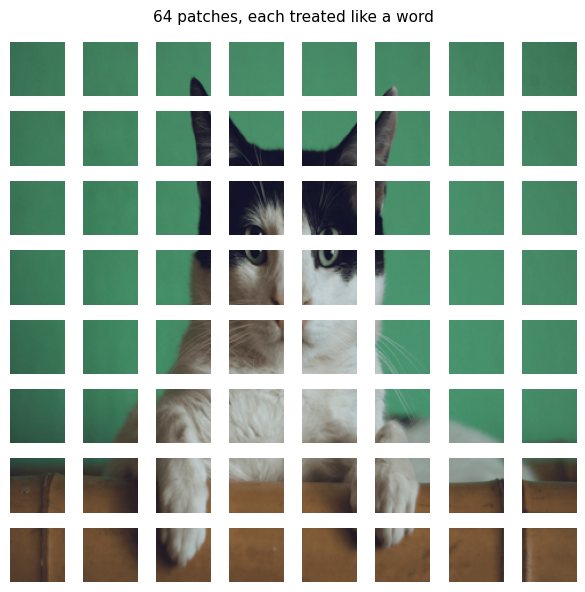

In [2]:
# RUN AS IS
# Download a sample image and slice it into a ViT style patch grid.
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/cat.png"
urllib.request.urlretrieve(url, "sample_cat.png")
img = Image.open("sample_cat.png").convert("RGB").resize((384, 384))

def show_patches(image, patch_size=48):
    """Slice an image into square patches and display them as a spaced grid,
    the way a Vision Transformer sees its input."""
    w, h = image.size
    cols, rows = w // patch_size, h // patch_size
    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    for r in range(rows):
        for c in range(cols):
            patch = image.crop((c * patch_size, r * patch_size,
                                (c + 1) * patch_size, (r + 1) * patch_size))
            axes[r, c].imshow(patch)
            axes[r, c].axis("off")
    fig.suptitle(f"{rows * cols} patches, each treated like a word", fontsize=11)
    plt.tight_layout()
    plt.show()

show_patches(img)

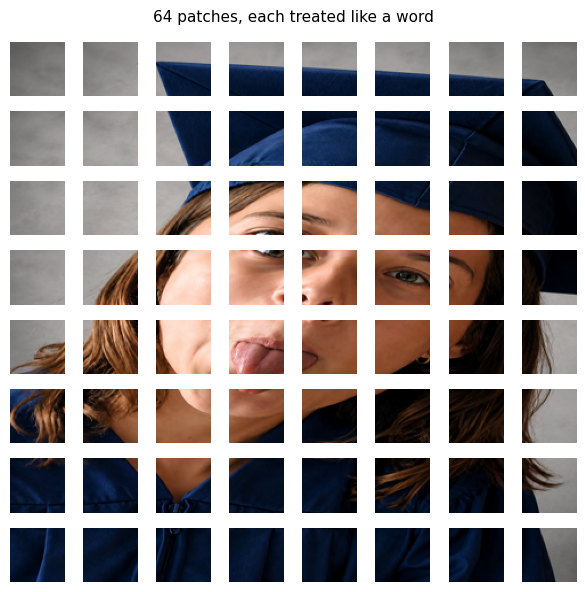

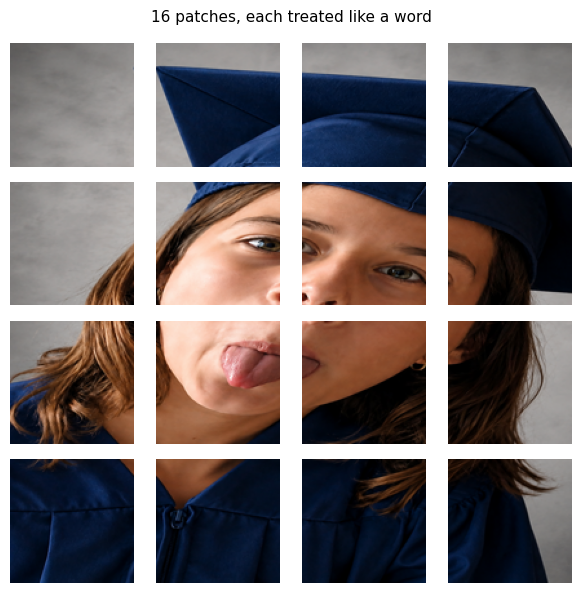

In [3]:
# YOUR CODE HERE (Patch grid, graded, 10 pts)

# TODO: load a DIFFERENT image (upload your own with the Colab folder icon,
#       or reuse a different URL) and display its patch grid at TWO patch
#       sizes: 48 and 96.
# Tip: resize to (384, 384) first so the grid divides evenly.
# Tip: img2 = Image.open("/content/yourfile.jpg").convert("RGB").resize((384, 384))
#      then call show_patches(img2, patch_size=48) and again with 96.

# TODO: your code here
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/4 grade.png").convert("RGB").resize((384, 384))

def show_patches(image, patch_size=48):
    """Slice an image into square patches and display them as a spaced grid,
    the way a Vision Transformer sees its input."""
    w, h = image.size
    cols, rows = w // patch_size, h // patch_size
    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    for r in range(rows):
        for c in range(cols):
            patch = image.crop((c * patch_size, r * patch_size,
                                (c + 1) * patch_size, (r + 1) * patch_size))
            axes[r, c].imshow(patch)
            axes[r, c].axis("off")
    fig.suptitle(f"{rows * cols} patches, each treated like a word", fontsize=11)
    plt.tight_layout()
    plt.show()

show_patches(img, patch_size=48)
show_patches(img, patch_size=96)

### YOUR ANSWER (Patches)

*Double click and replace: With 48 pixel patches versus 96 pixel patches, which grid would give the model a more detailed "sentence" to read, and what is the tradeoff? Answer in two or three sentences using the words of an image analogy.*

For me the 48 pixels, because displayed much 64 patches, against 16 patches from the 96 pixels.

## Section 3: Load the VLM and Have Your First Conversation

**RUN AS IS.** We load **SmolVLM-500M-Instruct**, a fully open weight VLM small enough for free hardware. Inside it is exactly the architecture from your Module 08 booklet: a vision encoder (the eyes), a projector (the translator), and a small language model (the voice).

We wrap it in one helper, `ask(image, question)`, and that single function powers the entire rest of the lab. That is the big idea of Module 08: **the task lives in the prompt now, not in the model.**

In [7]:
import transformers

print("AutoModelForVision2Seq:", "AutoModelForVision2Seq" in dir(transformers))
print("AutoModelForImageTextToText:", "AutoModelForImageTextToText" in dir(transformers))

AutoModelForVision2Seq: False
AutoModelForImageTextToText: True


In [8]:
# RUN AS IS
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, torch_dtype=DTYPE
).to(DEVICE)

def ask(image, question, max_new_tokens=150):
    """Ask the VLM one question about one image and return its answer."""
    messages = [{"role": "user",
                 "content": [{"type": "image"},
                             {"type": "text", "text": question}]}]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=prompt, images=[image], return_tensors="pt").to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    answer = processor.batch_decode(out, skip_special_tokens=True)[0]
    # The decoded text contains the whole conversation; keep only the reply.
    return answer.split("Assistant:")[-1].strip()

print("VLM loaded. Say hello:")
print(ask(img, "Describe this image in one sentence."))

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

VLM loaded. Say hello:
In this image we can see a woman wearing a cap and she is doing a tongue roll.


### YOUR TURN 1: Interview an Image (Graded, 10 pts)

Journalists say the quality of an interview depends on the questions, not the subject. Same here. Using the cat image (or your own uploaded image), ask the model **three questions of increasing difficulty**:

1. An easy factual question (what is in the image)
2. A detail question (color, position, count, background)
3. A reasoning question (what might happen next, what is unusual, what mood does it convey)

Print each question with its answer so both are visible in your output.

In [9]:
# YOUR CODE HERE (Your Turn 1)

# TODO: write your three questions and ask them.
# Tip: a loop keeps this readable:
# for q in [question_1, question_2, question_3]:
#     print("Q:", q)
#     print("A:", ask(img, q))
#     print()

question_1 = "What color is the cap?"
question_2 = "What the person is doing with the tongue?"
question_3 = "Why the person is doing this facial expression?"

for q in [question_1, question_2, question_3]:
    print("Q:", q)
    print("A:", ask(img, q))
    print()
# TODO: your loop here

Q: What color is the cap?
A: The cap is blue in color.

Q: What the person is doing with the tongue?
A: The person is sticking their tongue.

Q: Why the person is doing this facial expression?
A: The image does not provide information about the reason for the person's facial expression.



### YOUR ANSWER (Your Turn 1)

*Double click and replace: Which of your three questions got the weakest answer, and why do you think that level of question is harder for the model? Two or three sentences.*

The last question was the tricky one, since the photo does not translate feelings, that model was not able to identify why she was doing that facial expression.

## Section 4: One Model, Many Jobs (Graded, 10 pts)

Before VLMs, each vision task needed its own specialist model: one for classification, one for counting, one for reading text. A VLM replaces the whole shelf, because **the prompt selects the job**. Watch the demo, then make the model switch jobs yourself.

**Prompting tip that professionals rely on:** constrain the output format. "Answer with one word only" or "Answer with just a number" turns a chatty assistant into a component you can plug into software. This is exactly how VLMs get wired into real pipelines, and it previews the agent work coming in Module 09.

In [10]:
# RUN AS IS
# Job 1, classification: the prompt turns the VLM into a classifier.
print("Classifier:", ask(img, "Is this a cat, a dog, or a bird? Answer with one word only."))

Classifier: No.


In [11]:
# YOUR CODE HERE (Job switching)

# TODO: make the SAME model do two more jobs on the same image:
#   Job 2, counter: ask how many of something there are, demanding just a number.
#   Job 3, reader/describer: ask it to list every object it can see, one per line.
# Tip: the only thing you are allowed to change is the question string.
#      That is the whole point of this section.

# TODO: Job 2 here
print("Counter:", ask(img, "How many persons are in the image? Answer with one word only."))
# TODO: Job 3 here
print("reader/describer:", ask(img, "List all the objects that you can see, one per line."))

Counter: 1.
reader/describer: 1. Woman.


### YOUR ANSWER (One model, many jobs)

*Double click and replace: In Module 06 you used a dedicated detector (YOLO) for finding objects. Name one advantage the specialist detector still has over the VLM you just prompted, and one advantage the VLM has over the specialist. Two or three sentences.*

Yolo, can classify more objects than the VLM as en example, on my job3, the model list only: Woman, and it is missing the cap, and the gow.
VLM in another hand can count objects in the image something that Yolo cannot.

## Section 5: Workforce Task A, Accessibility Alt Text (Graded, 10 pts)

Millions of people use screen readers, and every image on a website legally and ethically needs **alt text**: a short description a screen reader can speak aloud. Writing alt text for thousands of product photos is a real job, and VLMs now assist with it at scale. But quality depends entirely on the prompt.

Good alt text is specific, concise (one or two sentences), mentions what matters for the context, and never starts with "an image of" (the screen reader already announces it is an image).

Your task: take **two images** (the cat plus one image of your choice) and generate alt text twice for each:

1. First with a **weak prompt**: just "Describe this image."
2. Then with a **professional prompt you write** that encodes the rules above.

In [12]:
# YOUR CODE HERE (Workforce task A)

# TODO: write your professional alt text prompt. Encode the rules:
#       concise, specific, useful for a shopper or reader, never "an image of".
# Tip: you can put instructions AND constraints in one question, for example:
#      "Write alt text for this image for a screen reader user. One sentence,
#       specific, do not begin with the words an image of."
from PIL import Image

cat_img = Image.open("/content/sample_cat.png").convert("RGB")
woman_img = Image.open("/content/4 grade.png").convert("RGB")

weak_prompt = "Describe this image."
pro_prompt = "Write short alt text for a screen reader, be clear and specific, include the most important details, and do not start with 'An image of.' "


# TODO: run both prompts on BOTH images and print all four results, clearly
#       labeled so the improvement is easy to see.

print("CAT IMAGE")
print("Weak prompt:", ask(cat_img, weak_prompt))
print()
print("CAT IMAGE")
print("Professional prompt:", ask(cat_img, pro_prompt))
print()
print("WOMAN IMAGE")
print("Weak prompt:", ask(woman_img, weak_prompt))
print()
print("WOMAN IMAGE")
print("Professional prompt:", ask(woman_img, pro_prompt))

CAT IMAGE
Weak prompt: The image depicts a domestic cat resting on a wooden surface, likely a table or shelf. The cat is predominantly white with patches of black on its head, ears, and paws. The fur on its face is white, while the fur on its chest and paws is black. The cat's eyes are green, and its nose is pink. The cat's left paw is extended forward, with the paw pads slightly spread apart, and its right paw is tucked underneath its body. The cat's ears are upright and its tail is not visible in the image.

The background of the image is a solid green color, which provides a stark contrast to the white and black fur of the cat. The green color is likely a studio backdrop, used to

CAT IMAGE
Professional prompt: A black and white cat is resting its head on a wooden surface.

WOMAN IMAGE
Weak prompt: The image depicts a young woman in the foreground, with a focus on her face and the object she is sticking her tongue out at. She is wearing a blue graduation cap, which is a traditional 

### YOUR ANSWER (Alt text)

*Double click and replace: Compare the weak and professional outputs. What specifically improved, and what would you still fix by hand before publishing? Two or three sentences.*    
The professional prompt produced much shorter and more focused alt text than the weak prompt. The weak prompt has many unnecessary details, while the professional prompt only described the main subject. I would still add a little more information because some important details, like the graduation cap, were missing from the professional output.

## Section 6: Workforce Task B, Reading Documents and Charts (Graded, 10 pts)

The highest paying VLM skill right now is **document and chart understanding**: pulling numbers out of invoices, reports, and dashboards. Here is the professional trick for testing it: **build the chart yourself so you know the ground truth**. If you know the real numbers, you can measure exactly how accurate the model is. Never trust an extraction you cannot check.

**RUN AS IS** builds a sales chart with known values. Then you interrogate it.

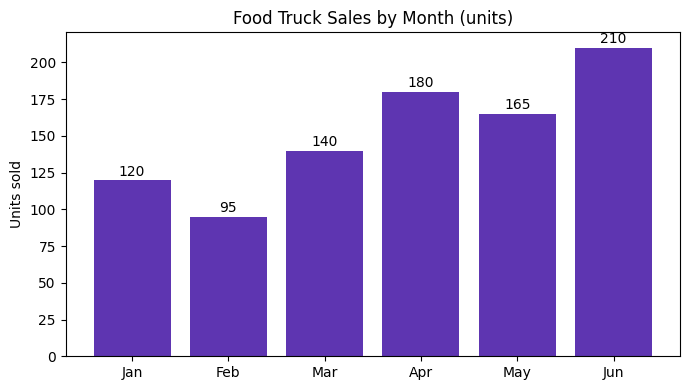

Chart built. Ground truth: {'Jan': 120, 'Feb': 95, 'Mar': 140, 'Apr': 180, 'May': 165, 'Jun': 210}


In [13]:
# RUN AS IS
# Build a bar chart with KNOWN values, save it, and load it as an image.
import matplotlib.pyplot as plt
from PIL import Image

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = [120, 95, 140, 180, 165, 210]   # ground truth, we KNOW these numbers

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(months, sales, color="#5E35B1")
ax.set_title("Food Truck Sales by Month (units)")
ax.set_ylabel("Units sold")
for i, v in enumerate(sales):
    ax.text(i, v + 3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("sales_chart.png", dpi=110)
plt.show()

chart = Image.open("sales_chart.png").convert("RGB")
print("Chart built. Ground truth:", dict(zip(months, sales)))

In [15]:
# YOUR CODE HERE (Workforce task B)

# TODO: ask the model AT LEAST three questions about the chart and print the
#       answers next to the true values so accuracy is visible. Ideas:
#   1. Which month had the highest sales?
#   2. How many units were sold in March? (Answer with just the number.)
#   3. Did sales go up or down between April and May?
# Tip: ask(chart, your_question)
# Tip: at least one question should require comparing two bars, which is
#      harder than reading one printed number.

# TODO: your questions here

q1 = "Which month had 95 units sold?"
q2 = "How many more units was sold in June than May? Answer with just number."
q3 = "January was the best sale's month?"

print("Question 1:", q1)
print("Model:", ask(chart,q1))
print("True answer: Feb")
print()
print("Question 2:", q2)
print("Model:", ask(chart,q2))
print("True answer: 45")
print()
print("Question 3:", q3)
print("Model:", ask(chart,q3))
print("True answer: no")

Question 1: Which month had 95 units sold?
Model: Feb.
True answer: Feb

Question 2: How many more units was sold in June than May? Answer with just number.
Model: 61.
True answer: 45

Question 3: January was the best sale's month?
Model: Yes.
True answer: no


### YOUR ANSWER (Chart reading)

*Double click and replace: Score the model: how many of your questions did it answer correctly against the ground truth? Would you trust it unsupervised with a company's financial dashboard? Two or three sentences.*
Answered just one question correctly, I does not trust, because the model was not able to do a simply math operation right like in the question 2: 210-165=45 and the model said 61.

## Section 7: YOUR TURN 2, The Hallucination Hunt (Graded, 10 pts)

Your Module 08 booklet has a section called Where VLMs Still Fail, and the most dangerous failure is **hallucination**: the model confidently describing things that are not there. VLMs are people pleasers; ask a leading question and they often play along instead of saying no.

Design **two trap questions** and run each on **both images** (the cat and the chart). A trap question presupposes something false, for example:

* "What color is the dog's collar?" (asked about an image with no dog)
* "What does the sign in the background say?" (no sign exists)
* "Why did sales drop in June?" (they rose)

A model passes the trap by correcting you. It fails by inventing an answer.

In [16]:
# YOUR CODE HERE (Your Turn 2)

# TODO: write two trap questions of your own (do not copy the examples) and
#       run each on BOTH images, printing all four exchanges clearly.
# Tip: the best traps sound casual and confident, exactly like a distracted
#      coworker would ask.

trap_1 = "Why Jan have bigger numbers than Feb?"
trap_2 = "What image is in the picture hanged on the wall?"

# TODO: run both traps on img and on chart, print all four Q and A pairs
print("CAT IMAGE")
print("trap_1:", ask(cat_img, trap_1))
print("trap_2:", ask(cat_img, trap_2))
print()
print("chart")
print("trap_1:", ask(chart, trap_1))
print("trap_2:", ask(chart, trap_2))
print()


CAT IMAGE
trap_1: There is no Jan or Feb mentioned in the image, and therefore no numbers can be assigned to them.
trap_2: There is a cat in the picture in the image.

chart
trap_1: Jan had a higher number of units sold than Feb.
trap_2: There is no image hanging on the wall in the picture.



### YOUR ANSWER (Hallucination report)

*Double click and replace: For each trap, did the model correct you or play along? Why is this failure mode more dangerous in a workplace than simply getting a count wrong? Three or four sentences.*


The model corrected me on two of the trap questions pointing that the information was not in the image. However, it was wrong with the other two questions instead of correcting the false statements. This is more dangerous in the workplace because people may trust the model's answer even when it is making up information. Getting a count wrong is a mistake, but hallucinating can lead to incorrect decisions based on false information.

## Section 8: Preview, The Agent's Eyes (Bridge to Module 09)

**RUN AS IS.** In Module 09 you will build AI agents that perceive, reason, and act. Their perception step is exactly what you have been doing all lab: a VLM answering questions about what it sees. Here is a thirty second preview: we ask the model not just to describe, but to **recommend an action**, which is the seed of the agent loop.

In [17]:
# RUN AS IS
# The same ask() function, but the prompt now requests a decision.
agent_question = (
    "You are a monitoring assistant for a pet daycare. Based on this camera "
    "image, report the situation in one sentence and recommend one action. "
    "Format: SITUATION: ... ACTION: ..."
)
print(ask(img, agent_question))

The situation is a pet daycare. Recommend one action is to monitor the pet daycare and ensure the pet is well-cared for.


Notice what changed: nothing in the model, everything in the prompt. Perception plus a decision format is the doorway to agents. Hold that thought for two weeks.

## Section 9: Try It Yourself, The Deployment Audit (Graded, 20 pts)

This section is fully yours. No scaffolding, no starter code. Your only tools: `ask()`, `show_patches()`, matplotlib, and your judgment.

**The scenario:** You are a junior CV technician. Your manager is considering using a small VLM for one workplace task and asks you to **audit it before anyone trusts it**. You choose the scenario:

* Retail: describing product photos for a store website
* Safety: reporting what is visible on a workplace camera image
* Accessibility: alt text for a community organization's photo library
* Education: describing diagrams or charts for students
* Your own idea (name it clearly)

**Your deliverable, in cells you write yourself:**

1. **The scenario and test set (5 pts):** name your scenario and assemble two or three test images that fit it (upload your own, reuse the chart trick from Section 6 to build controlled test images, or reuse the provided images if they genuinely fit).
2. **The reliability test (5 pts):** design ONE prompt for the task, then test it for consistency by asking the same thing **three different ways** (rephrase it twice) on the same image. A dependable tool gives consistent answers; a fragile one changes its story.
3. **The audit memo (10 pts):** in the answer cell below, write a five to eight sentence memo to your manager: what you tested, what the model got right, what it got wrong or inconsistent, one hallucination risk specific to your scenario, and your verdict: deploy with human review, deploy unsupervised, or do not deploy. Take a position and defend it with your evidence.

**GPU saver:** ten to fifteen questions total is plenty. A sharp audit beats a big one.

In [18]:
# YOUR CODE HERE (Try It Yourself)
# Build your audit below. Add as many cells as you need.
# Your toolbox:
#   ask(image, question)
#   show_patches(image, patch_size=...)
#   matplotlib and PIL for building controlled test images
# Reminder: print every question next to its answer so your memo's evidence
# is visible in the notebook output.

In [19]:
#1 Load the images.
from PIL import Image

img1 = Image.open("/content/Test_1.jpg").convert("RGB")
img2 = Image.open("/content/Test_2.jpg").convert("RGB")
img3 = Image.open("/content/Test_3.png").convert("RGB")

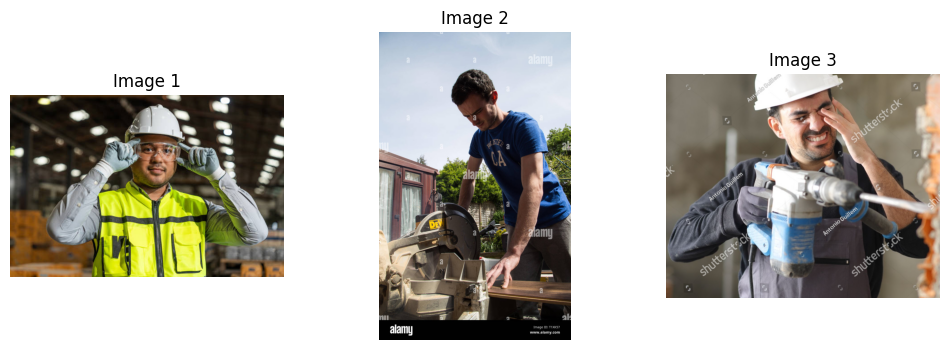

In [20]:
#2 Display the images
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img2)
plt.title("Image 2")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img3)
plt.title("Image 3")
plt.axis("off")

plt.show()

In [21]:
#3 Reliability test
prompt1 = "Is this person wearing all the required personal protective equipment (PPE)?"

prompt2 = "Does this person appear to be wearing the required safety equipment?"

prompt3 = "Based on this image, is the worker using the proper PPE?"

In [22]:
#4 Model test
images = [img1, img2, img3]
titles = ["Image 1", "Image 2", "Image 3"]

for img, title in zip(images, titles):

    print("=" * 50)
    print(title)

    print("\nQuestion 1:")
    print(ask(img, prompt1))

    print("\nQuestion 2:")
    print(ask(img, prompt2))

    print("\nQuestion 3:")
    print(ask(img, prompt3))

    print()

Image 1

Question 1:
Yes, the person is wearing a hard hat and safety glasses.

Question 2:
Yes, the person is wearing a safety helmet.

Question 3:
Yes, the worker is wearing a face mask and gloves.

Image 2

Question 1:
The person is not wearing any safety glasses, gloves, or ear protection.

Question 2:
The person is not wearing a helmet, which is a safety equipment typically worn when operating power tools.

Question 3:
The worker is wearing gloves, which is a common safety measure for workers.

Image 3

Question 1:
No, the person is wearing a hard hat, but there is no mention of PPE in the image.

Question 2:
Yes, the person is wearing a helmet.

Question 3:
Yes, the worker is wearing a hard hat.



### YOUR ANSWER (Audit memo)

*Double click and replace: your five to eight sentence memo to your manager. What you tested, what worked, what failed or wavered, one scenario specific hallucination risk, and your verdict with reasons.*  








I tested the VLM using three workplace safety images to evaluate whether it could identify PPE. The model correctly recognized some safety equipment, like hard hats and safety glasses, but its answers were not consistent. For example, it said the same worker was wearing safety glasses in one answer, a face mask and gloves in another, and only a helmet in a different response. It also missed some PPE or even worst, incorrectly reported equipment that was not clearly visible. The hallucination risk in this scenario is that the model may report workers are wearing safety equipment when they are not, or fail to identify missing PPE, which could create safety risks. My recommendation is to deploy this model only with human review because it can assist with inspections, but its inconsistent answers make it unreliable for making safety decisions on its own. One more time even know that the model is good, a double check by human eyes is always required.

## Section 10: Reflection Questions (Graded, 20 pts, 2 each)

Answer each question in complete sentences directly in its YOUR ANSWER cell. Short bullet answers will not earn full credit. I want your reasoning in your own words.

**Q1. Patches as words.** Explain to a friend with no AI background how a Vision Transformer reads an image, using the patch grid you made in Section 2. Use your own analogy, not one from this notebook.

### YOUR ANSWER

A vision transformer reads a image by breaking it into many small square pieces know as patches. I think of it like putting together a puzzle. Each puzzle piece gives a little information, and when the model looks at all the pieces together, it can understand what is in the whole image. A tip is smaller patches give more details, but the model has to process more pieces, which takes more work.


**Q2. The three part architecture.** A VLM has eyes (vision encoder), a translator (projector), and a voice (language model). When your model hallucinated in Section 7, which part do you suspect was most responsible, and why?

### YOUR ANSWER

 For me the language model was the most responsible for the hallucination. The vision encoder can only detect what is in the image, but the language model creates the final answer. In Section 7, it answered some questions with information that was not really in the image instead of saying it did not know. For me this shows that the language model sometimes tries to give an answer even when there is not enough visual evidence.


**Q3. The prompt is the task.** In Section 4 one model did several jobs. What does this mean for how CV teams will be organized in the workplace: fewer specialist models to maintain, or new problems to manage? Name one of each.

### YOUR ANSWER

I think CV teams will need fewer specialist models because one VLM can do many different tasks just changing the prompt. This can save time and make the system easier to maintain. However, there will also be new problems to manage, like making sure the prompts are clear and checking for hallucinations or incorrect answers. Even if one model can do many jobs, people still need to check the results to see if they are accurate before using them.


**Q4. Constrained outputs.** Why does "answer with just a number" matter so much when a VLM is wired into software instead of chatting with a person? Give a concrete example of what breaks without it.

### YOUR ANSWER

Saying "answer with just a number" is important because the software expects a specific format, if the model writes extra words or a complete sentence, the program may not understand the answer and could fail. Like, if a parking system asks how many cars are in the image, it expects something like "3.", but if the model answer is "I can see three cars in the parking lot," the software may not be able to use that result correctly.

**Q5. Small versus frontier.** You used a 500 million parameter open model today; Module 08 covered frontier models thousands of times larger. Name two workplace situations where the small local model is the RIGHT choice even though it is weaker.

### YOUR ANSWER

A small local model is a good choice when the company needs fast answers without sending data to the internet. Like, it can be used to monitor security cameras inside a factory where employee privacy is important. It is also a good choice for checking products on an assembly line because it can run on a local computer and make quick decisions. Even know it is not as powerful as a frontier model, it is faster, costs less, and keeps sensitive information private.

**Q6. Alt text ethics.** Who is harmed when auto generated alt text is wrong, and why is "a human reviews every caption" easier to promise than to deliver at the scale of a real website?

### YOUR ANSWER

People who depend on alt text, especially people with visual impairments, are harmed when the description is wrong or missing important details. They may not understand what is shown in the image or receive incorrect information. Having a human review every caption sounds like a good idea, but it is difficult for large websites because they may have thousands of new images uploaded every day. Reviewing every caption would take a lot of time and people.

**Q7. Ground truth.** In Section 6 you built the chart yourself so you knew the true numbers. Why is this a professional habit, and what goes wrong when teams evaluate AI tools on data where nobody knows the right answers?

### YOUR ANSWER

Knowing the ground truth is important because it lets us compare the model's answers with the correct answers and measure its accuracy. In Section 6, we knew the correct numbers because we created the chart ourselves. If nobody knows the right answers, it is difficult to tell whether the AI is correct or making mistakes. This can cause teams to trust a model that is actually giving incorrect information.

**Q8. Hallucination versus error.** Using your Section 7 results, explain the difference between a model being wrong and a model hallucinating. Why is the second one harder to catch in a busy workplace?

### YOUR ANSWER

A model is wrong when it gives an incorrect answer about something that is actually in the image. A hallucination is different because the model makes up information that is not in the image at all. In Section 7, the model sometimes answered questions using details that were not actually visible instead of saying it did not know. Hallucinations are harder to catch in a busy workplace because the answers can sound trusty, so people may trust them without double check.

**Q9. The audit mindset.** Your Try It Yourself verdict required taking a position. What evidence would have changed your verdict to the opposite one? Being able to answer this is what separates an audit from an opinion.

### YOUR ANSWER

My decision would have changed if the model had given consistent and accurate answers for all three safety images. For example, it should correctly identify the same PPE every time, no matter how the question is written, and avoid reporting equipment that is not visible. If the results were reliable across different images and prompts, I mean after training the model in a big dataset not only 3 images, I would recommend using the model without requiring as much human review.

**Q10. Changed mind.** Before this lab, what did you believe about how AI understands images that turned out to be wrong or incomplete? Be specific about which section changed your mind.

### YOUR ANSWER

Before this lab, I believed that AI understood images almost the same way people do, I know from previous work that they does not see the image the way we see. After completing Section 7, I realized that the model can sound very confident even when it is making up information that is not in the image. This changed my mind because I learned that AI does not always understand what it sees, so its answers should be checked before making important decisions.

## Section 11: Optional Bonus Challenges (up to +20)

Each completed challenge earns 5 bonus points. Pick any, all, or none. All four are light on compute.

**Bonus A, The tiny sibling (+5):** Load `HuggingFaceTB/SmolVLM-256M-Instruct` (half the size, a fast extra download) and rerun your three Your Turn 1 questions on it. In one or two sentences: what did shrinking the model cost?

**Bonus B, The receipt reader (+5):** Using PIL, draw your own fake receipt image (store name, three items with prices, a total) with `ImageDraw.text`, then ask the model to extract the total and one item price. You know the ground truth because you drew it.

**Bonus C, The patch size probe (+5):** Take one image with small important detail (text or a small object). Show its patch grid at 96 pixels, then ask the model a question about that small detail. Connect what you see in the grid to how the model answered, in one or two sentences.

**Bonus D, Your own photo set (+5):** Complete your Try It Yourself audit entirely with photos you took yourself. If you already did, say so here and point to the cells.

In [24]:
# YOUR CODE HERE (Optional bonus work)
# Label each attempt clearly with a comment: # BONUS A, # BONUS B, etc.
# Memory tip for Bonus A: load the 256M model AFTER you finish everything
# else, and if memory complains, run:
#   del model; import gc; gc.collect(); torch.cuda.empty_cache()
# before loading the smaller one.

In [23]:
#Bonus a - load the smaller model

from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

model_name = "HuggingFaceTB/SmolVLM-256M-Instruct"

processor = AutoProcessor.from_pretrained(model_name)

model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

if torch.cuda.is_available():
    model = model.to("cuda")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.2k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/3.55M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

In [26]:
#bonus a - test the small model

print("Question 1:", question_1)
print("Answer:")
print(ask(img, question_1))

print("\n" + "="*60 + "\n")

print("Question 2:", question_2)
print("Answer:")
print(ask(img, question_2))

print("\n" + "="*60 + "\n")

print("Question 3:", question_3)
print("Answer:")
print(ask(img, question_3))

Question 1: What color is the cap?
Answer:
The cap is white.


Question 2: What the person is doing with the tongue?
Answer:
The person is holding the tongue with their hand.


Question 3: Why the person is doing this facial expression?
Answer:
The person is doing this facial expression to show that they are angry or upset.


Bonus a.
The smaller model made more mistakes.Named the blue graduation cap as white and gave incorrect answers about what the person was doing and why. Shrinking the model reduced its accuracy and its ability to understand the image.

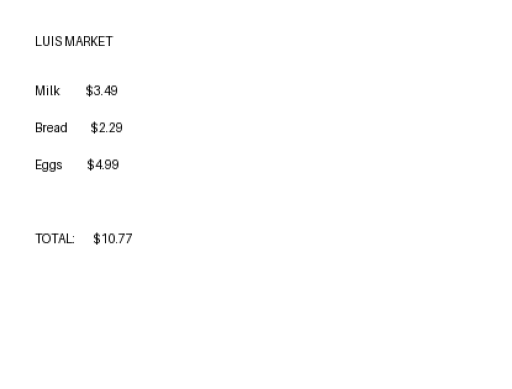

In [27]:
#bonus b - creating the fake receipt

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

receipt = Image.new("RGB", (400, 300), "white")
draw = ImageDraw.Draw(receipt)

font = ImageFont.load_default()

draw.text((20, 20), "LUIS MARKET", fill="black", font=font)
draw.text((20, 60), "Milk          $3.49", fill="black", font=font)
draw.text((20, 90), "Bread         $2.29", fill="black", font=font)
draw.text((20,120), "Eggs          $4.99", fill="black", font=font)

draw.text((20,180), "TOTAL:       $10.77", fill="black", font=font)

plt.imshow(receipt)
plt.axis("off")
plt.show()

In [28]:
#bonus b - ask the model

question_1 = "What is the total on the receipt?"
question_2 = "What is the price of the bread?"

print("Question 1:", question_1)
print(ask(receipt, question_1))

print("\n" + "="*60 + "\n")

print("Question 2:", question_2)
print(ask(receipt, question_2))

Question 1: What is the total on the receipt?
The total on the receipt is $10.77.


Question 2: What is the price of the bread?
The price of the bread is $2.29.


bonus b.
The model was able to right provide the total and the price of the bread from the receipt. Since I created the receipt myself, I knew the correct answers before testing the model, making it easy to verify that the results were accurate.

## Section 12: Submission Checklist

1. Choose Runtime, then Run all, one final time. Confirm there are no errors and every question and answer pair is visible.
2. Check that every **YOUR ANSWER** cell has your words in it (search the notebook for the word "replace" to find any you missed).
3. File, Download, Download .ipynb, **with all outputs visible**. Do not clear outputs.
4. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit the notebook to Canvas. The notebook is the only deliverable.

Today you interviewed images, made one model wear five hats, caught it lying, and wrote a professional audit, all on a model small enough to run on a laptop. In Module 09 the VLM you just tamed becomes the **eyes of an agent** that perceives, reasons, and acts. You already wrote its first perception prompt in Section 8.

*Email or message me if you have any questions.*